# CSCI 3151 — Foundations of Machine Learning

**Module M04 – Supervised learning via regression, risk, and loss**

In this mini-lab, we'll work with a tiny synthetic dataset of students, their study time, and exam scores. We'll treat this as a **supervised regression** problem and walk through parts of the supervised learning pipeline:

- framing the prediction task and stakeholders,
- computing **empirical risk** from data,
- comparing different **loss functions** for regression.

We'll imagine this model could be used to support decisions like offering tutoring or scholarships, so the **costs of prediction errors** matter.

**This mini-lab reinforces…**

- The idea of a **supervised learning pipeline** (data, model, loss, evaluation).
- The distinction between **expected risk** and **empirical risk** on a finite dataset.
- How different **regression loss functions** (MSE vs MAE) change model preferences.
- Simple **1D linear regression** as a model for supervised prediction.



## Assumptions & simplifications

- You are comfortable with:
  - basic Python (`lists`, `dict`, `for` loops),
  - using **NumPy** and **pandas** at the level of earlier course labs,
  - plotting simple figures with **Matplotlib**.
- We use a **small synthetic dataset** instead of real institutional data:
  - real educational data would be messier (missing values, more covariates, selection bias, etc.),
  - our DGP is intentionally simple and approximately linear.
- We focus on:
  - a single numeric input feature (`hours_studied`) and a numeric target (`exam_score`),
  - a **single train/test split** (no cross-validation yet),
  - only two loss functions (MSE and MAE), even though many others exist.
- Some of the more advanced math and 3D loss-surface plots from the video slides
  are **omitted or simplified here** to keep this activity doable in ~30 minutes.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(3151)

# Make plots appear inline in Jupyter
%matplotlib inline

print("Libraries imported. NumPy version:", np.__version__)


Libraries imported. NumPy version: 2.5.3


In [16]:
# ---------------------------------------------------------------------
# Create a small synthetic regression dataset: study hours -> exam score
# ---------------------------------------------------------------------

n_students = 40

# Hours studied between 0 and 10
hours = np.random.uniform(low=0, high=10, size=n_students)

# Underlying linear relationship: exam_score ≈ 45 + 4.5 * hours + noise
true_w0 = 45.0
true_w1 = 4.5

noise = np.random.normal(loc=0.0, scale=6.0, size=n_students)
scores = true_w0 + true_w1 * hours + noise

# Introduce one "weird" student (an outlier): high study hours but low score
hours[0] = 9.5
scores[0] = 40.0  # much lower than the linear trend would suggest

data = pd.DataFrame({
    "student_id": np.arange(1, n_students + 1),
    "hours_studied": hours,
    "exam_score": scores
})

data.head()


,student_id,hours_studied,exam_score
0,1,9.500000,40.000000
1,2,5.843840,69.103757
2,3,9.739514,91.966710
3,4,0.910574,43.989157
4,5,7.451842,74.913180


## Core Task 1 – Connect the pipeline to this dataset

In the video, we talked about the **supervised learning pipeline**:
1. Problem & stakeholders
2. Data & labels (DGP)
3. Split data (train / validation / test)
4. Choose model family
5. Choose loss & evaluation metric(s)
6. Train (minimize empirical risk)
7. Evaluate & stress-test
8. Decide & deploy

In this lab we'll only touch a subset of these steps, but we still want to
**think like pipeline designers**, not just people running code.

### Your turn (edit this cell):

Answer **briefly** in your own words:

1. **Task definition**  
   - What are we trying to predict?  
   - What input information are we allowed to use?

2. **Stakeholders & costs**  
   - Name at least two stakeholders (people or groups) who might care about
     this model's predictions.  
   - Which kind of error do you think is more costly here: **overestimating**
     a student's score or **underestimating** it? Why?

3. **Sanity-checking the DGP**  
   - Look at the variable names and units. What *assumptions* about the
     data-generating process are we making when we fit a straight line?

*(Write your answers directly underneath this text.)*


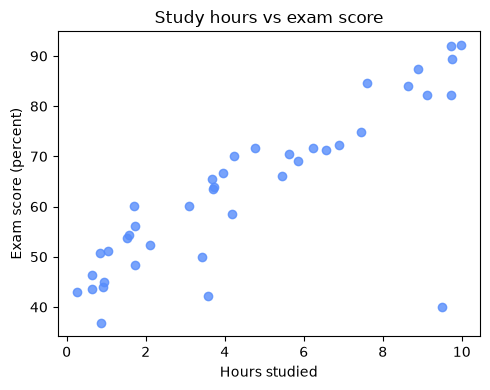

In [27]:
# Quick visual sanity-check: scatter plot of hours vs exam score

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(data["hours_studied"], data["exam_score"], alpha=0.8)

ax.set_xlabel("Hours studied")
ax.set_ylabel("Exam score (percent)")
ax.set_title("Study hours vs exam score")

plt.tight_layout()
plt.show()


## Core Task 2 – Empirical risk for a fixed linear model

In the slides, **expected risk** is the average loss over the *true* (unknown)
data distribution, while **empirical risk** is the average loss over our
finite dataset.

Here we'll practice computing empirical risk for a **fixed linear model**.

We'll consider a model of the form:

\[
f_\theta(x) = w_1 x + w_0.
\]

Below, we'll define some candidate parameters `(w0, w1)` and ask you to:

1. Implement helper functions for **mean squared error (MSE)** and
   **mean absolute error (MAE)**.
2. Compute the empirical MSE and MAE for one candidate model on the full dataset.
3. Reflect on which loss is more sensitive to our outlier student.


In [18]:
# Helper functions for regression losses

def mse_loss(y_pred, y_true):
    """Return the mean squared error between predictions and targets.
    
    Parameters
    ----------
    y_pred : array-like
        Predicted values.
    y_true : array-like
        True target values.
    """
    # TODO: implement MSE using NumPy
    y_pred = np.asarray(y_pred)
    y_true = np.asarray(y_true)
    # YOUR CODE HERE
    mse = None
    return mse


def mae_loss(y_pred, y_true):
    """Return the mean absolute error between predictions and targets."""
    # TODO: implement MAE using NumPy
    y_pred = np.asarray(y_pred)
    y_true = np.asarray(y_true)
    # YOUR CODE HERE
    mae = None
    return mae


# Quick self-check (uncomment after you implement):
# y_true_test = np.array([1.0, 2.0, 3.0])
# y_pred_test = np.array([1.0, 1.0, 5.0])
# print("MSE test:", mse_loss(y_pred_test, y_true_test))   # expect > 0
# print("MAE test:", mae_loss(y_pred_test, y_true_test))   # expect > 0


In [19]:
# Choose a simple candidate model by hand
w0_candidate = 40.0
w1_candidate = 5.0

# Compute predictions for all students
y_pred = w0_candidate + w1_candidate * data["hours_studied"].values
y_true = data["exam_score"].values

print("First 5 predictions:", y_pred[:5])

# TODO: use your loss functions to compute empirical MSE and MAE
mse_full = None  # replace with mse_loss(...)
mae_full = None  # replace with mae_loss(...)

print(f"Empirical MSE on full dataset: {mse_full}")
print(f"Empirical MAE on full dataset: {mae_full}")


First 5 predictions: [87.5        69.21920008 88.69757159 44.55287147 77.25921077]
Empirical MSE on full dataset: None
Empirical MAE on full dataset: None


### Short reflection (no code)

1. Which loss (MSE or MAE) is **more sensitive** to a single very bad prediction?
2. In this dataset, which student is most likely to drive a big difference
   between MSE and MAE? Why?

*(Write 2–4 sentences here.)*


## Core Task 3 – Comparing models under MSE vs MAE

We'll now compare **three** candidate linear models on our dataset.

Each model has parameters `(w0, w1)` chosen by hand. Your job is to:

1. Compute empirical MSE and MAE for **each** model.
2. Rank the models from best → worst under:
   - MSE
   - MAE
3. Notice whether the **ranking changes** when we switch losses.


In [20]:
# Three hand-picked candidate models (intercept, slope)
candidates = {
    "Model A": (45.0, 4.0),
    "Model B": (40.0, 5.0),
    "Model C": (50.0, 3.5),
}

results = []

for name, (w0, w1) in candidates.items():
    y_pred = w0 + w1 * data["hours_studied"].values
    y_true = data["exam_score"].values
    
    # TODO: compute losses using your functions
    mse = None  # mse_loss(...)
    mae = None  # mae_loss(...)
    
    results.append({
        "model": name,
        "w0": w0,
        "w1": w1,
        "mse": mse,
        "mae": mae,
    })

results_df = pd.DataFrame(results)
results_df


,model,w0,w1,mse,mae
0,Model A,45.0,4.0,None,None
1,Model B,40.0,5.0,None,None
2,Model C,50.0,3.5,None,None


### Follow-up questions

1. Based on your table above, rank the three models from best → worst
   under **MSE**.
2. Do you get the same ranking under **MAE**? If not, which model benefits
   from using MAE instead of MSE, and why might that be?
3. If your stakeholders are very worried about **occasional huge errors**
   (e.g., missing a student who is struggling badly), which loss would you
   argue for in the training objective? Explain in 2–3 sentences.


## Stretch Tasks (optional)

If you finish the core tasks early, try one or more of these:

### Stretch 1 – Train/test split and generalization

1. Use `sklearn.model_selection.train_test_split` to split the dataset into
   a **70% train** and **30% test** set (remember to set `random_state=3151`).
2. Fit a `sklearn.linear_model.LinearRegression` model on the **train** set.
3. Compute MSE and MAE separately on:
   - the training data,
   - the test data.
4. Do you see signs of **overfitting** or **underfitting** yet?

### Stretch 2 – Outlier sensitivity

1. Re-run your MSE and MAE calculations **without** the outlier student
   (row with `student_id == 1`).
2. Compare how much each loss changes when you remove that data point.
3. What does this tell you about **robustness** to outliers?

### Stretch 3 – Different DGP

1. Modify the data generation code so that the relationship between
   `hours_studied` and `exam_score` is **non-linear** (e.g., saturating
   at high hours).
2. Re-run your analysis from Core Task 3.
3. How does the linear model misrepresent the new DGP? Where are the
   biggest residuals in input space?


In [21]:
# You can use this cell (and add more) for the stretch tasks.
# For example, here's a starting point for a train/test split
# once you've imported scikit-learn in a new cell:

# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression

# X = data[["hours_studied"]].values  # 2D array for sklearn
# y = data["exam_score"].values

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=3151
# )
